In [1]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter

%matplotlib widget

(1400.0, 2000.0)

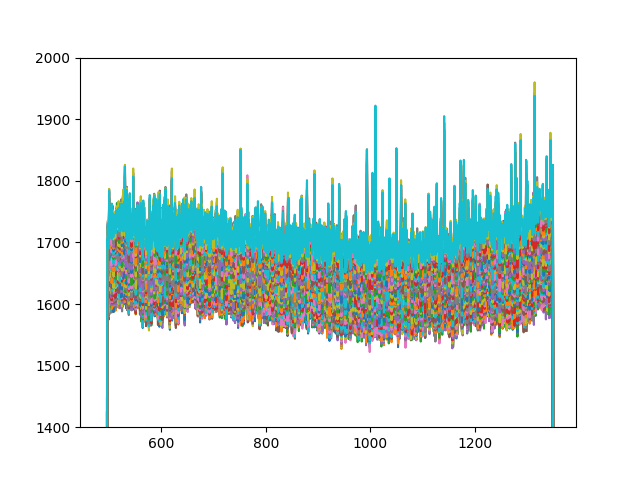

In [3]:
dark = np.loadtxt('20250715 dark_it test.csv')
wl = dark[:, 0]
dark = dark[:, 2:-1]  # Exclude the first two columns (wavelength and lamp ref) and the last
fig = plt.figure()
plt.plot(wl, dark)
plt.ylim(1400, 2000)

In [59]:
spectra = np.loadtxt('20250715 final_it test.csv', skiprows=1)

wl = spectra[:,0]
int_t = np.arange(5, 401, 5) # from the CSV file header
central_int_time = 205
cit_index = np.where(int_t == central_int_time)[0][0]
sp_start = spectra[:, 1]
sp_end = spectra[:, -1]
spectra = spectra[:, 2:-1]  # Exclude the first two columns (wavelength and lamp ref) and the last
spectra[spectra > 60000] = np.nan  # Cutout at 64k
spectra = spectra - dark
spectra = spectra[30:1501, :]  # No signal outside this range
wl = wl[30:1501]  # Adjust wavelength array to match spectra

Text(0.5, 0, 'Wavelength (nm)')

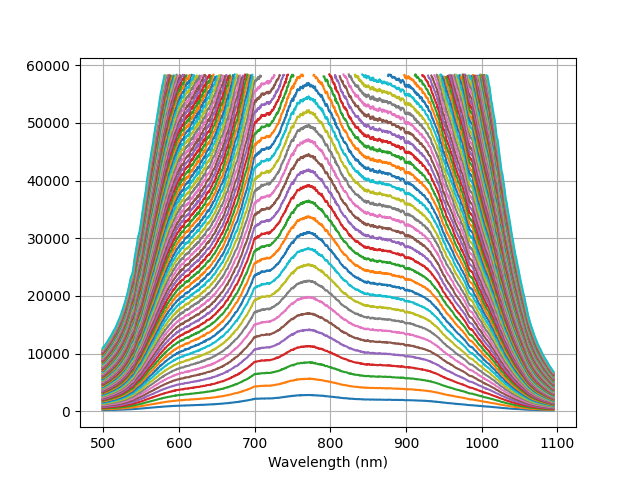

In [60]:
fig = plt.figure()
plt.plot(wl, spectra)
plt.grid()
plt.xlabel('Wavelength (nm)')

(500.0, 1100.0)

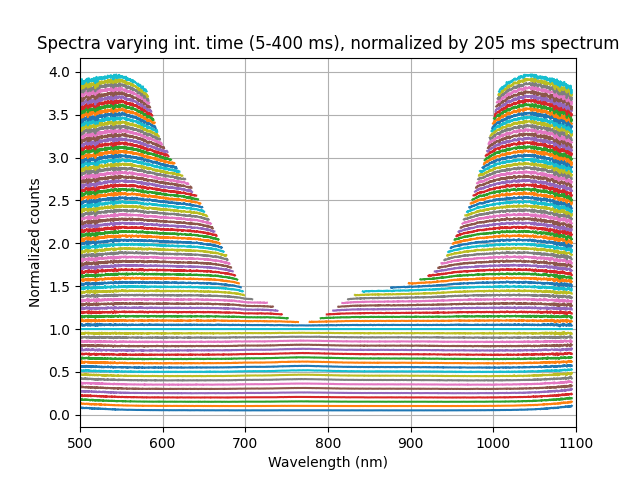

In [69]:
# normalize by a single integration time spectrum
norm_int_time = 100
norm_index = np.where(int_t == norm_int_time)[0][0]
sn = spectra[:,] / spectra[:,norm_index][:, np.newaxis]
fig = plt.figure()
plt.plot(wl, sn)
plt.grid()
plt.xlabel('Wavelength (nm)')
plt.ylabel('Normalized counts')
plt.title(f'Spectra varying int. time ({int_t[0]}-{int_t[-1]} ms), normalized by {central_int_time} ms spectrum')
plt.xlim(500, 1100)

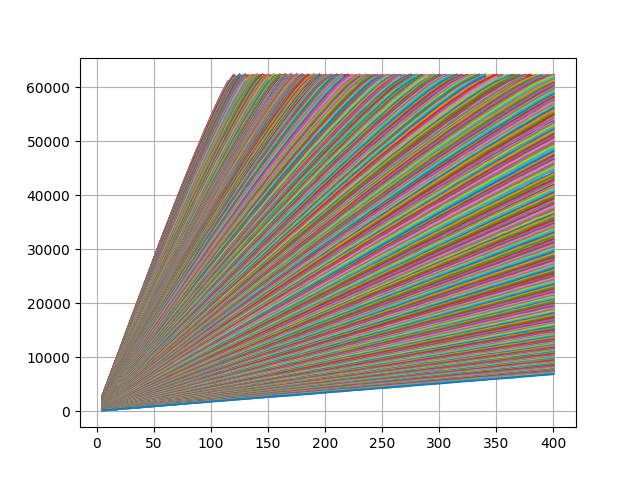

In [22]:
plt.figure()
plt.plot(int_t, spectra.T)
plt.grid()

In [62]:
# Fit a regression line through the origin: y = a*x
mask = ~np.isnan(spectra)
a = np.array(
    [np.linalg.lstsq(int_t[:, np.newaxis][mask[s]], spectra[s, :][mask[s]], rcond=None)[0][0] for s in range(spectra.shape[0])]
)

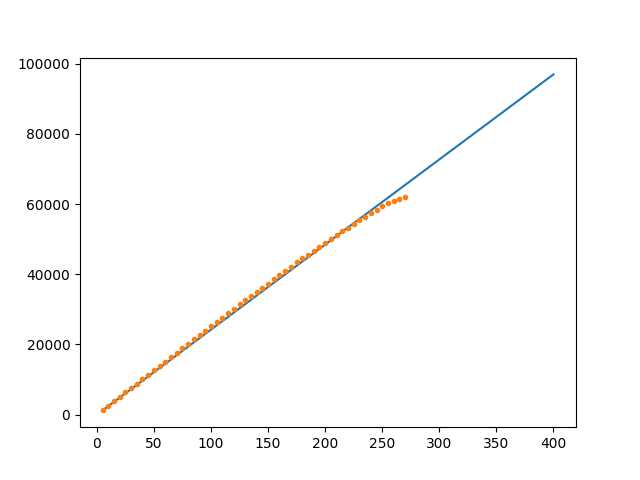

In [51]:
plt.figure()
s = 415
plt.plot(int_t, a[s] * int_t, label='fit')
plt.plot(int_t, spectra[s, :], marker='.', linestyle='None', label='data')

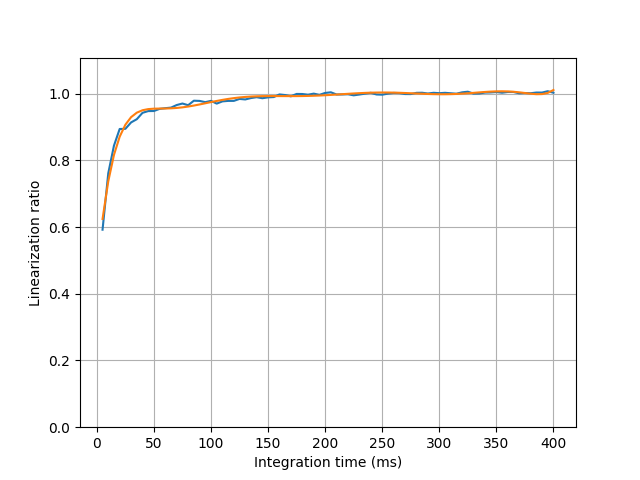

interactive(children=(IntSlider(value=25, description='s', max=1470), Output()), _dom_classes=('widget-interac…

In [68]:
from ipywidgets import interact, IntSlider
import ipywidgets as widgets
from IPython.display import display

li = (np.tile(int_t, (spectra.shape[0], 1))*a[:,np.newaxis]).T  # linearized intensity
ratio = li / spectra.T
p_coeffs = [np.polynomial.Polynomial.fit(int_t[mask[s]], ratio[:, s][mask[s]], deg=9) for s in range(spectra.shape[0])]

plt.figure()
s = 25
l = plt.plot(int_t, ratio[:,s])
f = plt.plot(int_t, p_coeffs[s](int_t))
plt.xlabel('Integration time (ms)')
plt.ylabel('Linearization ratio')
plt.ylim(0, np.max(ratio[:,s]) * 1.1)
plt.grid()
plt.show()

@interact(s=IntSlider(min=0, max=spectra.shape[0]-1, step=1, value=s))
def update(s=25):
    l[0].set_ydata(ratio[:,s])
    f[0].set_ydata(p_coeffs[s](int_t))


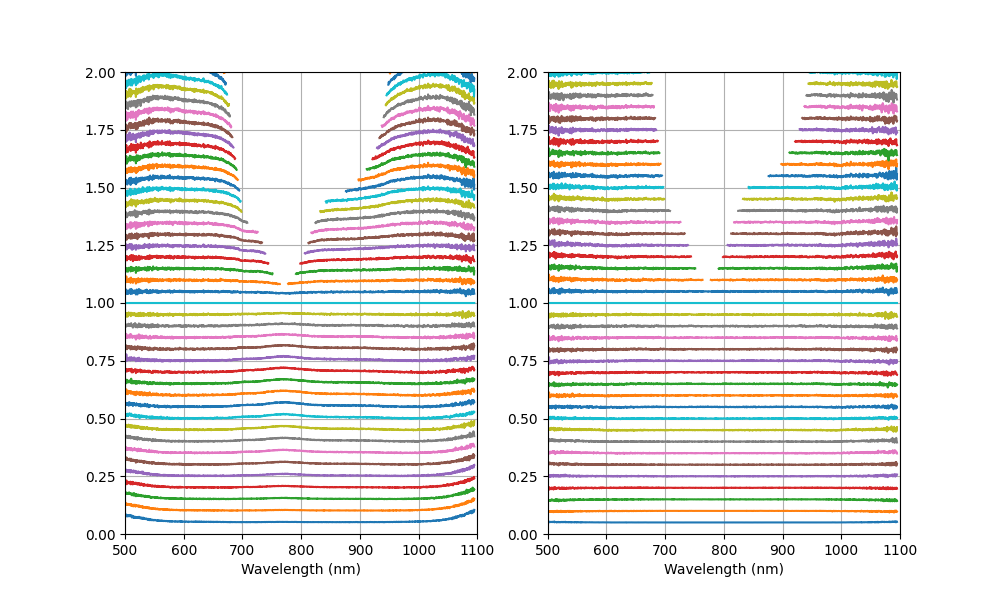

In [78]:
# normalize by the center column
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
spectra_lin = np.array([spectra[s]*p_coeffs[s](int_t) for s in range(spectra.shape[0])])
sn_lin = spectra_lin[:,] / spectra_lin[:,norm_index][:, np.newaxis]
axes[0].plot(wl, sn)
axes[1].plot(wl, sn_lin)
for ax in axes:
    ax.grid()
    ax.set_xlabel('Wavelength (nm)')
    ax.set_xlim(500, 1100)
    ax.set_ylim(0, 2.0)

In [89]:
p1 = np.polynomial.Polynomial([1])
np.save('20250715 linearizatinon coeffs.npy', [p1]*30 + p_coeffs + [p1]*547)  # outside of the domain, no linearization